# Notebook 08 — Explainable AI with SHAP

This notebook explains the final XGBoost intrusion-detection model
using SHAP feature-attribution values.

In [1]:
# ============================================================
# IMPORT LIBRARIES AND CONFIGURE PATHS
# ============================================================

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed"
)

MODELS_PATH = (
    PROJECT_ROOT / "data" / "models"
)

FIGURES_PATH = (
    PROJECT_ROOT / "results" / "figures"
)

EXPLAINABILITY_PATH = (
    PROJECT_ROOT / "results" / "explainability"
)

FIGURES_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

EXPLAINABILITY_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

TRAIN_PATH = (
    PROCESSED_DATA_PATH / "CICIDS2017_train.csv"
)

TEST_PATH = (
    PROCESSED_DATA_PATH / "CICIDS2017_test.csv"
)

MODEL_PATH = (
    MODELS_PATH / "xgboost_final_exp2.pkl"
)

SCALER_PATH = (
    MODELS_PATH / "xgboost_final_scaler.pkl"
)

LABEL_ENCODER_PATH = (
    MODELS_PATH / "xgboost_label_encoder.pkl"
)

print("✅ Libraries and project paths configured.")

✅ Libraries and project paths configured.


In [2]:
# ============================================================
# LOAD SAVED XGBOOST MODEL, SCALER, LABEL ENCODER, AND TEST DATA
# ============================================================

assert MODEL_PATH.exists(), (
    f"Model not found: {MODEL_PATH.resolve()}"
)

assert SCALER_PATH.exists(), (
    f"Scaler not found: {SCALER_PATH.resolve()}"
)

assert LABEL_ENCODER_PATH.exists(), (
    f"Label encoder not found: {LABEL_ENCODER_PATH.resolve()}"
)

assert TEST_PATH.exists(), (
    f"Test data not found: {TEST_PATH.resolve()}"
)

# Load the final Experiment 2 XGBoost model artifacts.
final_model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

# Load the same held-out test data used in Notebook 05.
test_df = pd.read_csv(TEST_PATH)

# Original_Row_ID identifies source rows and is not a model feature.
feature_columns = [
    column
    for column in test_df.columns
    if column not in ["Label", "Original_Row_ID"]
]

X_test = test_df[feature_columns].copy()

y_test = label_encoder.transform(
    test_df["Label"]
)

# Apply the exact scaler saved with the final XGBoost model.
X_test_scaled = scaler.transform(X_test)

# Keep feature names for understandable SHAP visualizations.
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
)

print("✅ Final XGBoost model and test data loaded.")
print("Test shape:", X_test_scaled_df.shape)
print("Number of classes:", len(label_encoder.classes_))
print("Classes:", list(label_encoder.classes_))

✅ Final XGBoost model and test data loaded.
Test shape: (504160, 47)
Number of classes: 15
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# ============================================================
# SELECT A FIXED SAMPLE FOR FAST, REPRODUCIBLE EXPLANATIONS
# ============================================================

RANDOM_SEED = 42
SHAP_SAMPLE_SIZE = min(1_000, len(X_test_scaled_df))

X_explain = X_test_scaled_df.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_SEED,
)

print("✅ SHAP sample created.")
print("Records selected for explanation:", len(X_explain))

✅ SHAP sample created.
Records selected for explanation: 1000


In [4]:
# ============================================================
# CREATE TREE SHAP EXPLAINER AND CALCULATE SHAP VALUES
# ============================================================

explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer(
    X_explain
)

print("✅ SHAP values calculated successfully.")
print("SHAP value shape:", shap_values.values.shape)

✅ SHAP values calculated successfully.
SHAP value shape: (1000, 47, 15)


In [5]:
# ============================================================
# CALCULATE MEAN ABSOLUTE SHAP VALUE FOR EVERY FEATURE
# ============================================================

shap_array = shap_values.values

# Multiclass SHAP values have:
# samples × features × classes.
if shap_array.ndim == 3:
    mean_absolute_shap = np.abs(
        shap_array
    ).mean(axis=(0, 2))

else:
    mean_absolute_shap = np.abs(
        shap_array
    ).mean(axis=0)

global_importance_df = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Mean Absolute SHAP Value": mean_absolute_shap,
    }
).sort_values(
    by="Mean Absolute SHAP Value",
    ascending=False,
).reset_index(
    drop=True
)

print("✅ Global feature importance calculated.")
global_importance_df.head(20)

✅ Global feature importance calculated.


,Feature,Mean Absolute SHAP Value
0,Destination_Port,0.843001
1,Init_Win_bytes_backward,0.389938
2,min_seg_size_forward,0.315803
3,Fwd_Packet_Length_Max,0.253695
4,Init_Win_bytes_forward,0.235685
5,Fwd_IAT_Min,0.233323
6,Packet_Length_Mean,0.209181
7,Bwd_Packet_Length_Max,0.198664
8,Bwd_Packets_s,0.181113
9,Flow_IAT_Min,0.176545


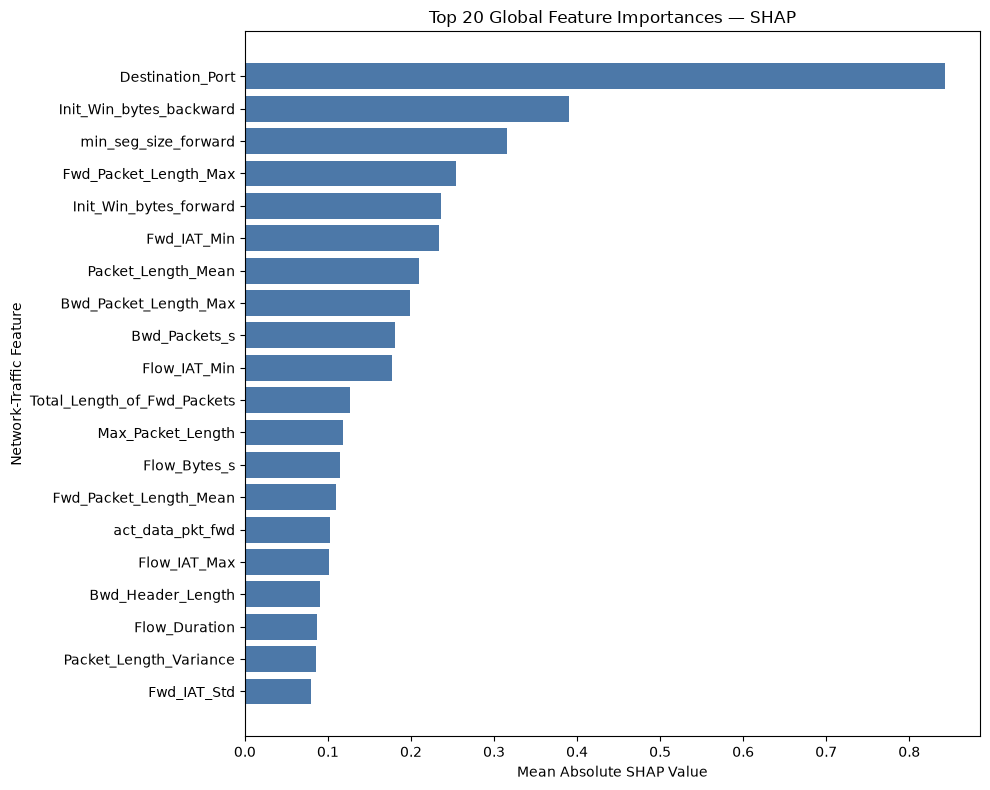

✅ Global SHAP chart saved to:
C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\figures\shap_global_feature_importance.png


In [6]:
# ============================================================
# PLOT THE 20 MOST IMPORTANT XGBOOST FEATURES
# ============================================================

top_features = global_importance_df.head(20).sort_values(
    by="Mean Absolute SHAP Value",
    ascending=True,
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"],
    color="#4C78A8",
)

plt.title(
    "Top 20 Global Feature Importances — SHAP"
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Network-Traffic Feature")
plt.tight_layout()

GLOBAL_IMPORTANCE_FIGURE_PATH = (
    FIGURES_PATH / "shap_global_feature_importance.png"
)

plt.savefig(
    GLOBAL_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Global SHAP chart saved to:")
print(GLOBAL_IMPORTANCE_FIGURE_PATH.resolve())

In [7]:
# ============================================================
# SELECT THE FIRST NON-BENIGN CLASS FOR A CLASS-SPECIFIC PLOT
# ============================================================

benign_class_index = next(
    (
        index
        for index, label in enumerate(label_encoder.classes_)
        if str(label).upper() == "BENIGN"
    ),
    0,
)

EXPLAIN_CLASS_INDEX = next(
    (
        index
        for index in range(len(label_encoder.classes_))
        if index != benign_class_index
    ),
    0,
)

EXPLAIN_CLASS_NAME = label_encoder.classes_[
    EXPLAIN_CLASS_INDEX
]

print(
    "✅ Selected class for detailed explanation:",
    EXPLAIN_CLASS_NAME,
)

✅ Selected class for detailed explanation: Bot


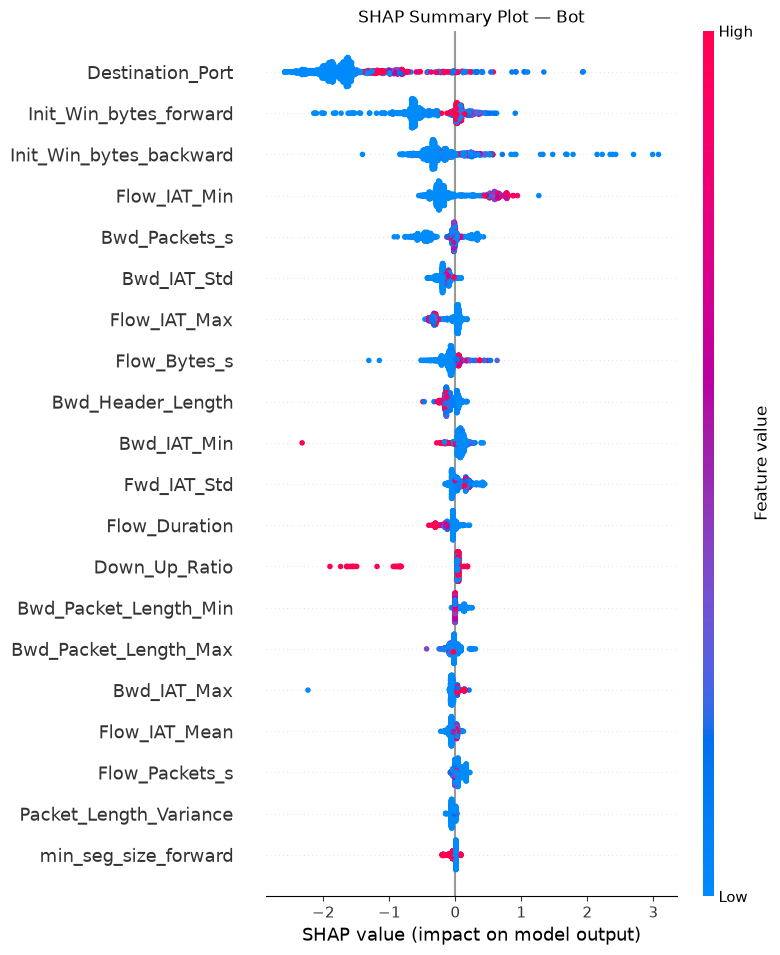

✅ Class-specific SHAP summary chart saved to:
C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\figures\shap_class_summary_plot.png


In [8]:
# ============================================================
# SHOW HOW FEATURES PUSH PREDICTIONS TOWARD OR AWAY FROM
# THE SELECTED ATTACK CLASS
# ============================================================

if shap_array.ndim == 3:
    class_shap_values = shap_array[
        :,
        :,
        EXPLAIN_CLASS_INDEX,
    ]

else:
    class_shap_values = shap_array

plt.figure(figsize=(10, 8))

shap.summary_plot(
    class_shap_values,
    X_explain,
    max_display=20,
    show=False,
)

plt.title(
    f"SHAP Summary Plot — {EXPLAIN_CLASS_NAME}"
)

CLASS_SUMMARY_FIGURE_PATH = (
    FIGURES_PATH / "shap_class_summary_plot.png"
)

plt.savefig(
    CLASS_SUMMARY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("✅ Class-specific SHAP summary chart saved to:")
print(CLASS_SUMMARY_FIGURE_PATH.resolve())

Predicted class: BENIGN


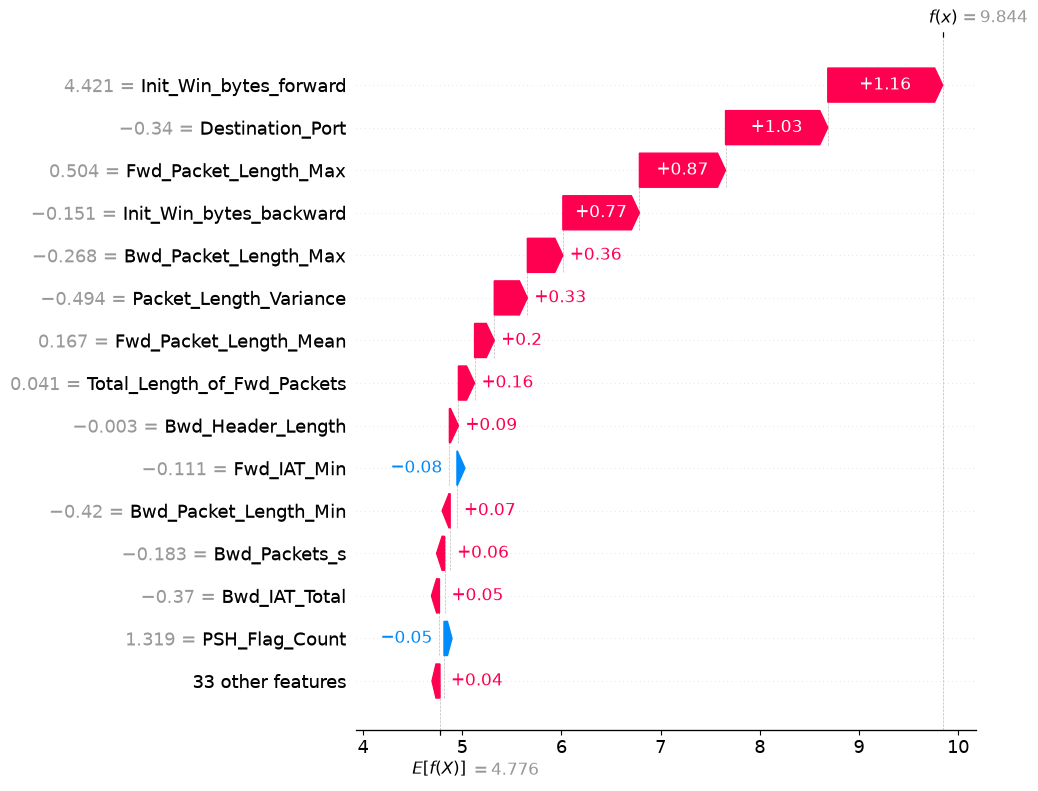

✅ Local explanation generated. Positive SHAP values support the predicted class; negative values oppose it.


In [9]:
# ============================================================
# EXPLAIN WHY XGBOOST MADE ONE SPECIFIC PREDICTION
# ============================================================

LOCAL_SAMPLE_INDEX = 0

local_record = X_explain.iloc[
    [LOCAL_SAMPLE_INDEX]
]

local_prediction_index = int(
    final_model.predict(local_record)[0]
)

local_prediction_label = label_encoder.inverse_transform(
    [local_prediction_index]
)[0]

if shap_array.ndim == 3:
    local_shap_explanation = shap_values[
        LOCAL_SAMPLE_INDEX,
        :,
        local_prediction_index,
    ]

else:
    local_shap_explanation = shap_values[
        LOCAL_SAMPLE_INDEX
    ]

print("Predicted class:", local_prediction_label)

shap.plots.waterfall(
    local_shap_explanation,
    max_display=15,
)

print(
    "✅ Local explanation generated. "
    "Positive SHAP values support the predicted class; "
    "negative values oppose it."
)

In [10]:
# ============================================================
# SAVE GLOBAL SHAP FEATURE IMPORTANCE VALUES
# ============================================================

GLOBAL_IMPORTANCE_PATH = (
    EXPLAINABILITY_PATH / "shap_global_feature_importance.csv"
)

global_importance_df.to_csv(
    GLOBAL_IMPORTANCE_PATH,
    index=False,
)

print("✅ SHAP feature-importance table saved to:")
print(GLOBAL_IMPORTANCE_PATH.resolve())

global_importance_df.head(20)

✅ SHAP feature-importance table saved to:
C:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\results\explainability\shap_global_feature_importance.csv


,Feature,Mean Absolute SHAP Value
0,Destination_Port,0.843001
1,Init_Win_bytes_backward,0.389938
2,min_seg_size_forward,0.315803
3,Fwd_Packet_Length_Max,0.253695
4,Init_Win_bytes_forward,0.235685
5,Fwd_IAT_Min,0.233323
6,Packet_Length_Mean,0.209181
7,Bwd_Packet_Length_Max,0.198664
8,Bwd_Packets_s,0.181113
9,Flow_IAT_Min,0.176545


In [11]:
# ============================================================
# PRINT A SHORT, REPORT-READY INTERPRETATION
# ============================================================

top_five_features = global_importance_df.head(5)[
    "Feature"
].tolist()

print("EXPLAINABLE AI SUMMARY")
print("=" * 55)

print(
    "Model explained: Final Experiment 2 XGBoost"
)

print(
    "Top five influential features:"
)

for rank, feature in enumerate(
    top_five_features,
    start=1,
):
    print(f"{rank}. {feature}")

print("\nInterpretation:")
print(
    "SHAP values identify which network-traffic features had "
    "the strongest influence on the XGBoost model predictions. "
    "They explain model behaviour, not causal relationships."
)

EXPLAINABLE AI SUMMARY
Model explained: Final Experiment 2 XGBoost
Top five influential features:
1. Destination_Port
2. Init_Win_bytes_backward
3. min_seg_size_forward
4. Fwd_Packet_Length_Max
5. Init_Win_bytes_forward

Interpretation:
SHAP values identify which network-traffic features had the strongest influence on the XGBoost model predictions. They explain model behaviour, not causal relationships.
